# Account Predictor - Model Training

This notebook trains machine learning models to predict account categories from transaction data.

## Approach:
- **Random Forest** - Best for tabular data with mixed features
- **Train/Validation/Test split** - 70/15/15 for robust evaluation
- **Data randomization** - Shuffle before splitting to avoid temporal bias
- **Feature engineering** - Extract meaningful patterns from dates, amounts, and descriptions


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print("Random seed set to 42 for reproducibility")


Libraries imported successfully!
Random seed set to 42 for reproducibility


## 1. Load and Prepare Data


In [27]:
# Load your transaction data
df = pd.read_csv('../data/data_template.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
print(df.head())

# Check for missing values
print(f"\nMissing values:")
print(df.isnull().sum())


Dataset shape: (2574, 6)
Columns: ['Date', 'Description', 'Account', ' Amount ', 'Unnamed: 4', 'Unnamed: 5']

First few rows:
        Date                   Description                  Account   Amount   \
0  21-Jul-23                         Jump+          Office Supplies   -91.98    
1  31-Jul-23              COSTCO WHOLESALE          Office Supplies  -400.99    
2  31-Jul-23              STARBUCKS COFFEE  Meals and Entertainment    -7.42    
3   1-Dec-23  PRE-AUTH PYMT - OTFS FEE BPY             Bank Charges   -40.00    
4   2-Jan-24  PRE-AUTH PYMT - OTFS FEE BPY             Bank Charges    -3.50    

   Unnamed: 4  Unnamed: 5  
0         NaN         NaN  
1         NaN         NaN  
2         NaN         NaN  
3         NaN         NaN  
4         NaN         NaN  

Missing values:
Date              0
Description       0
Account           0
 Amount           0
Unnamed: 4     2574
Unnamed: 5     2574
dtype: int64


In [28]:
# Clean the data
print("Cleaning data...")

# Remove any rows with missing critical data
df = df.dropna(subset=['Date', 'Description', 'Account'])

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Handle Excel errors in Date column
print("Checking for Excel errors in Date column...")
excel_errors = df['Date'].astype(str).str.contains('#VALUE!|#REF!|#NAME?', na=False)
if excel_errors.any():
    print(f"Found {excel_errors.sum()} rows with Excel errors in Date column")
    print("Removing these rows...")
    df = df[~excel_errors]

# Convert Date to datetime with error handling
print("Converting dates...")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove rows where date conversion failed
date_na = df['Date'].isna()
if date_na.any():
    print(f"Removing {date_na.sum()} rows with invalid dates...")
    df = df[~date_na]

# Clean Amount column (remove commas and convert to float)
print("Cleaning amounts...")
df['Amount'] = df['Amount'].astype(str).str.replace(',', '').str.replace(' ', '')
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# Remove rows with invalid amounts
amount_na = df['Amount'].isna()
if amount_na.any():
    print(f"Removing {amount_na.sum()} rows with invalid amounts...")
    df = df[~amount_na]

# Remove zero amounts (not useful for prediction)
zero_amounts = df['Amount'] == 0
if zero_amounts.any():
    print(f"Removing {zero_amounts.sum()} rows with zero amounts...")
    df = df[~zero_amounts]

# Filter classes with sufficient samples for better model performance
print("Filtering classes with sufficient samples...")
class_counts = df['Account'].value_counts()
min_samples = 20  # Only keep classes with 20+ samples
valid_classes = class_counts[class_counts >= min_samples].index

print(f"Classes with >= {min_samples} samples: {len(valid_classes)}")
print(f"Removed classes: {len(class_counts) - len(valid_classes)}")

if len(class_counts) - len(valid_classes) > 0:
    print("Removed classes:")
    removed_classes = class_counts[class_counts < min_samples]
    for class_name, count in removed_classes.items():
        print(f"  - {class_name}: {count} samples")

# Filter data to only include valid classes
df = df[df['Account'].isin(valid_classes)].copy()

print(f"After cleaning and filtering: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Amount range: ${df['Amount'].min():.2f} to ${df['Amount'].max():.2f}")

# Show account distribution
print(f"\nFinal account categories ({df['Account'].nunique()} total):")
print(df['Account'].value_counts())


Cleaning data...
Checking for Excel errors in Date column...
Converting dates...
Cleaning amounts...
Filtering classes with sufficient samples...
Classes with >= 20 samples: 14
Removed classes: 23
Removed classes:
  - Rent Expense: 17 samples
  - Personal Expenses: 16 samples
  - Interest: 13 samples
  - Purchases: 10 samples
  - Dispatcher Expense: 9 samples
  - Repair and Maintenance: 8 samples
  - Utilities: 7 samples
  - Accounting fees: 7 samples
  - Waste Management: 6 samples
  - Sub-contract : 6 samples
  - Loan : 5 samples
  - Interest Income: 5 samples
  - Cleaning Expense: 4 samples
  - Repair and maintenance: 3 samples
  - Office Supplies: 2 samples
  - Ask my Accountant: 2 samples
  - Intercompany: 2 samples
  - Postage & Courier: 2 samples
  - Corporation tax payable: 1 samples
  - Ask my accountant: 1 samples
  - Professional Fees: 1 samples
  - GST Payment: 1 samples
  - Cash: 1 samples
After cleaning and filtering: (2445, 6)
Date range: 2019-09-09 00:00:00 to 2030-07-2

## 2. Feature Engineering


In [29]:
# Create features from the data
print("Creating features...")

# Date features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['Quarter'] = df['Date'].dt.quarter

# Amount features
df['Amount_Abs'] = df['Amount'].abs()
df['IsIncome'] = (df['Amount'] > 0).astype(int)
df['Amount_Log'] = np.log1p(df['Amount_Abs'])  # log(1 + amount) to handle zeros

# Description features
df['Description_Length'] = df['Description'].str.len()
df['Word_Count'] = df['Description'].str.split().str.len()
df['Has_Numbers'] = df['Description'].str.contains(r'\d').astype(int)
df['Has_Special_Chars'] = df['Description'].str.contains(r'[!@#$%^&*(),.?":{}|<>]').astype(int)

# Clean descriptions for TF-IDF
def clean_text(text):
    """Clean transaction descriptions"""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = ' '.join(text.split())
    return text

df['Description_Clean'] = df['Description'].apply(clean_text)

# TF-IDF features for text analysis
print("Creating TF-IDF features...")
tfidf = TfidfVectorizer(
    max_features=300,  # Reduced for better performance
    min_df=5,          # Word must appear in at least 5 documents
    max_df=0.7,        # Word must appear in less than 70% of documents
    stop_words='english',
    ngram_range=(1, 2)  # Include both single words and 2-word phrases
)

tfidf_matrix = tfidf.fit_transform(df['Description_Clean'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f'tfidf_{word}' for word in tfidf.get_feature_names_out()],
    index=df.index
)

print(f"Created {tfidf_df.shape[1]} TF-IDF features")

# Combine basic features with TF-IDF features
basic_features = [
    'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'Quarter',
    'Amount_Abs', 'IsIncome', 'Amount_Log',
    'Description_Length', 'Word_Count', 'Has_Numbers', 'Has_Special_Chars'
]

X_basic = df[basic_features].copy()
X_combined = pd.concat([X_basic, tfidf_df], axis=1)

print(f"Total features created: {X_combined.shape[1]}")
print(f"Basic features: {len(basic_features)}")
print(f"TF-IDF features: {tfidf_df.shape[1]}")


Creating features...


Creating TF-IDF features...
Created 300 TF-IDF features
Total features created: 313
Basic features: 13
TF-IDF features: 300


## 3. Text Feature Engineering with Vocabulary


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler
import re

# Clean and preprocess text descriptions
def clean_text(text):
    """Clean transaction descriptions for better feature extraction"""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove special characters but keep spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Apply text cleaning
df['Description_Clean'] = df['Description'].apply(clean_text)

print("Sample cleaned descriptions:")
for i in range(5):
    print(f"Original: {df['Description'].iloc[i]}")
    print(f"Cleaned:  {df['Description_Clean'].iloc[i]}")
    print()


Sample cleaned descriptions:
Original: STARBUCKS COFFEE
Cleaned:  starbucks coffee

Original: PRE-AUTH PYMT - OTFS FEE BPY
Cleaned:  pre auth pymt otfs fee bpy

Original: PRE-AUTH PYMT - OTFS FEE BPY
Cleaned:  pre auth pymt otfs fee bpy

Original: TRANSFER 50356SF01OB3
Cleaned:  transfer 50356sf01ob3

Original: PRE-AUTH PYMT - OTFS FEE BPY
Cleaned:  pre auth pymt otfs fee bpy



In [31]:
# Create TF-IDF features from descriptions
print("Creating TF-IDF features...")

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=1000,  # Top 1000 most important words
    min_df=2,           # Word must appear in at least 2 documents
    max_df=0.95,        # Word must appear in less than 95% of documents
    stop_words='english', # Remove common English words
    ngram_range=(1, 2)   # Use both single words and 2-word phrases
)

# Fit and transform the descriptions
tfidf_matrix = tfidf.fit_transform(df['Description_Clean'])

# Convert to DataFrame for easier handling
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f'tfidf_{word}' for word in tfidf.get_feature_names_out()],
    index=df.index
)

print(f"Created {tfidf_df.shape[1]} TF-IDF features")
print("Top 20 most important words:")
feature_importance = tfidf_df.sum().sort_values(ascending=False)
print(feature_importance.head(20))


Creating TF-IDF features...
Created 768 TF-IDF features
Top 20 most important words:
tfidf_canada              112.122669
tfidf_deposit              95.641658
tfidf_fee                  80.042150
tfidf_transfer             78.009696
tfidf_square               66.402243
tfidf_square canada        66.253327
tfidf_uber                 61.382677
tfidf_interac              59.381263
tfidf_com                  54.397128
tfidf_msp div              52.819803
tfidf_msp                  52.819803
tfidf_div                  52.819803
tfidf_interac transfer     52.682732
tfidf_direct deposit       52.165810
tfidf_direct               52.165810
tfidf_canada msp           51.635855
tfidf_deposit square       51.338942
tfidf_google               48.580224
tfidf_account              48.366428
tfidf_uber canada          47.011038
dtype: float64


In [32]:
# Combine all features
print("Combining all features...")

# Select non-text features
feature_columns = [
    'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'Quarter',
    'Amount_Abs', 'IsIncome', 'Amount_Log',
    'Description_Length', 'Word_Count', 'Has_Numbers', 'Has_Special_Chars'
]

# Create feature matrix
X_basic = df[feature_columns].copy()

# Combine with TF-IDF features
X_combined = pd.concat([X_basic, tfidf_df], axis=1)

# Target variable
y = df['Account'].copy()

print(f"Final feature matrix shape: {X_combined.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Number of account categories: {y.nunique()}")

# Show feature types
print(f"\nFeature breakdown:")
print(f"- Basic features: {X_basic.shape[1]}")
print(f"- TF-IDF features: {tfidf_df.shape[1]}")
print(f"- Total features: {X_combined.shape[1]}")


Combining all features...
Final feature matrix shape: (2445, 781)
Target variable shape: (2445,)
Number of account categories: 14

Feature breakdown:
- Basic features: 13
- TF-IDF features: 768
- Total features: 781


## 4. Data Splitting with Randomization


In [33]:
# CRITICAL: Randomize data before splitting to avoid temporal bias
print("Randomizing data to avoid temporal bias...")

# First, filter out classes with too few samples (less than 3)
print("Filtering out classes with too few samples...")
class_counts = y.value_counts()
min_samples_per_class = 3
valid_classes = class_counts[class_counts >= min_samples_per_class].index

print(f"Original classes: {len(class_counts)}")
print(f"Classes with >= {min_samples_per_class} samples: {len(valid_classes)}")
print(f"Removed classes: {len(class_counts) - len(valid_classes)}")

if len(class_counts) - len(valid_classes) > 0:
    print("Removed classes:")
    removed_classes = class_counts[class_counts < min_samples_per_class]
    for class_name, count in removed_classes.items():
        print(f"  - {class_name}: {count} samples")

# Filter data to only include valid classes
valid_mask = y.isin(valid_classes)
df_filtered = df[valid_mask].copy()
X_filtered = X_combined[valid_mask].copy()
y_filtered = y[valid_mask].copy()

print(f"\nAfter filtering: {len(df_filtered)} samples")

# Create a copy and shuffle
df_shuffled = df_filtered.copy()
X_shuffled = X_filtered.copy()
y_shuffled = y_filtered.copy()

# Shuffle the data
shuffled_indices = np.random.permutation(len(df_shuffled))
df_shuffled = df_shuffled.iloc[shuffled_indices].reset_index(drop=True)
X_shuffled = X_shuffled.iloc[shuffled_indices].reset_index(drop=True)
y_shuffled = y_shuffled.iloc[shuffled_indices].reset_index(drop=True)

print(f"Data randomized. Date range after shuffle:")
print(f"First 5 dates: {df_shuffled['Date'].head().tolist()}")
print(f"Last 5 dates: {df_shuffled['Date'].tail().tolist()}")

# Split into train/validation/test (70/15/15)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_shuffled, y_shuffled, 
    test_size=0.15, 
    random_state=42, 
    stratify=y_shuffled
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.176,  # 0.176 * 0.85 = 0.15 (15% of total)
    random_state=42, 
    stratify=y_temp
)

print(f"\nData split:")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_shuffled)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X_shuffled)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X_shuffled)*100:.1f}%)")

# Check class distribution in each set
print(f"\nClass distribution:")
print("Training:", y_train.value_counts().head(5))
print("Validation:", y_val.value_counts().head(5))
print("Test:", y_test.value_counts().head(5))


Randomizing data to avoid temporal bias...
Filtering out classes with too few samples...
Original classes: 14
Classes with >= 3 samples: 14
Removed classes: 0



After filtering: 2445 samples
Data randomized. Date range after shuffle:
First 5 dates: [Timestamp('2024-02-29 00:00:00'), Timestamp('2024-07-09 00:00:00'), Timestamp('2024-10-18 00:00:00'), Timestamp('2024-09-24 00:00:00'), Timestamp('2024-12-23 00:00:00')]
Last 5 dates: [Timestamp('2024-04-12 00:00:00'), Timestamp('2024-06-07 00:00:00'), Timestamp('2024-07-23 00:00:00'), Timestamp('2022-06-13 00:00:00'), Timestamp('2024-05-01 00:00:00')]

Data split:
Training set: 1712 samples (70.0%)
Validation set: 366 samples (15.0%)
Test set: 367 samples (15.0%)

Class distribution:
Training: Account
Sales                      291
Office Expense             267
Meals and Entertainment    226
Bank Charges               222
Fees and Susbription       161
Name: count, dtype: int64
Validation: Account
Sales                      62
Office Expense             57
Meals and Entertainment    48
Bank Charges               47
Fees and Susbription       35
Name: count, dtype: int64
Test: Account
Sales      

## 5. Model Training - Random Forest


In [34]:
# Train Random Forest model with improved parameters
print("Training Random Forest model...")

# Initialize Random Forest with improved parameters for better performance
rf_model = RandomForestClassifier(
    n_estimators=300,        # More trees for better performance
    max_depth=12,            # Reduced depth to prevent overfitting
    min_samples_split=15,    # Increased to prevent overfitting
    min_samples_leaf=8,      # Increased to prevent overfitting
    random_state=42,         # For reproducibility
    n_jobs=-1               # Use all CPU cores
)

# Train the model
rf_model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Number of features used: {rf_model.n_features_in_}")
print(f"Number of classes: {len(rf_model.classes_)}")

# Make predictions on validation set
y_val_pred = rf_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"\nValidation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")


Training Random Forest model...


Model trained successfully!
Number of features used: 781
Number of classes: 14

Validation Accuracy: 0.7213 (72.13%)


## 6. Hyperparameter Tuning


In [35]:
# Hyperparameter tuning with GridSearchCV
print("Performing hyperparameter tuning...")

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',      # Use accuracy as the metric
    n_jobs=-1,              # Use all CPU cores
    verbose=1               # Show progress
)

# Fit the grid search
print("This may take a few minutes...")
grid_search.fit(X_train, y_train)

# Get the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.4f} ({best_score*100:.2f}%)")

# Train final model with best parameters
best_rf_model = grid_search.best_estimator_


Performing hyperparameter tuning...
This may take a few minutes...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score: 0.9182 (91.82%)


## 7. Model Evaluation


Evaluating model on test set...
Test Accuracy: 0.9264 (92.64%)

Detailed Classification Report:
                         precision    recall  f1-score   support

            Advertising       1.00      0.92      0.96        12
     Automobile Expense       0.88      0.96      0.92        23
           Bank Charges       0.98      0.98      0.98        47
               Donation       1.00      0.83      0.91         6
     Due to Shareholder       1.00      0.93      0.96        14
   Fees and Susbription       0.94      0.91      0.93        35
      Insurance Expense       1.00      0.80      0.89         5
Meals and Entertainment       0.80      0.92      0.86        49
         Office Expense       0.89      0.82      0.85        57
                  Sales       0.95      0.98      0.97        62
      Telephone Expense       1.00      1.00      1.00        10
 Transfer Between Banks       1.00      1.00      1.00        22
         Travel Expense       0.95      0.90      0.93    

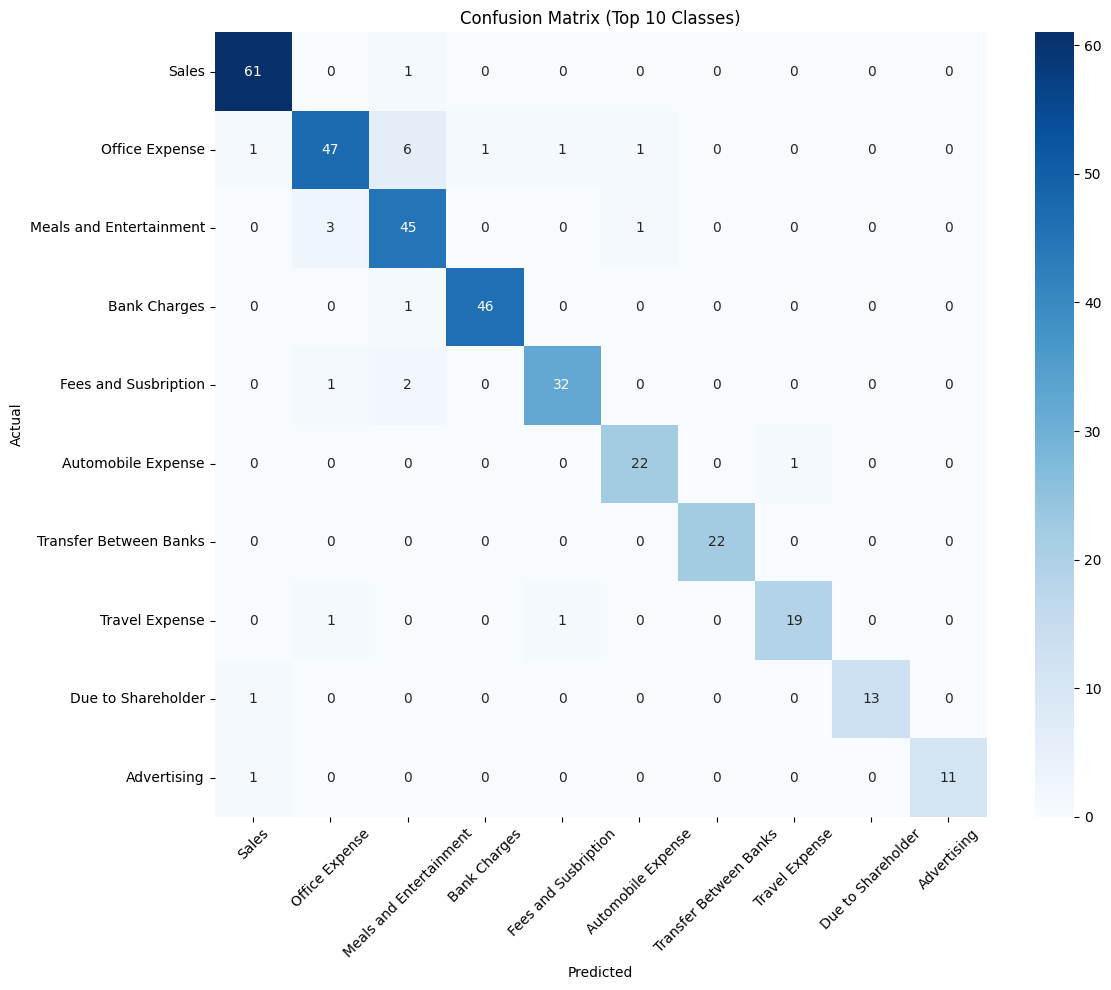

In [36]:
# Evaluate on test set (unseen data)
print("Evaluating model on test set...")

# Make predictions on test set
y_test_pred = best_rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
print("\nConfusion Matrix (Top 10 classes):")
cm = confusion_matrix(y_test, y_test_pred)
classes = best_rf_model.classes_

# Get top 10 most frequent classes for better visualization
top_classes = y_test.value_counts().head(10).index
top_class_indices = [list(classes).index(cls) for cls in top_classes if cls in classes]

if top_class_indices:
    cm_subset = cm[np.ix_(top_class_indices, top_class_indices)]
    classes_subset = [classes[i] for i in top_class_indices]
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes_subset, yticklabels=classes_subset)
    plt.title('Confusion Matrix (Top 10 Classes)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 8. Feature Importance Analysis


Analyzing feature importance...
Top 20 Most Important Features:
                feature  importance
6            Amount_Abs    0.051837
8            Amount_Log    0.050307
9    Description_Length    0.037497
7              IsIncome    0.036492
2                   Day    0.029148
329           tfidf_fee    0.028143
10           Word_Count    0.017918
290       tfidf_deposit    0.016980
1                 Month    0.015110
265           tfidf_com    0.014287
3             DayOfWeek    0.013692
202        tfidf_canada    0.013035
12    Has_Special_Chars    0.011534
732          tfidf_uber    0.011386
5               Quarter    0.010747
11          Has_Numbers    0.009359
545         tfidf_petro    0.009337
142         tfidf_apple    0.008503
0                  Year    0.008445
715      tfidf_transfer    0.008331


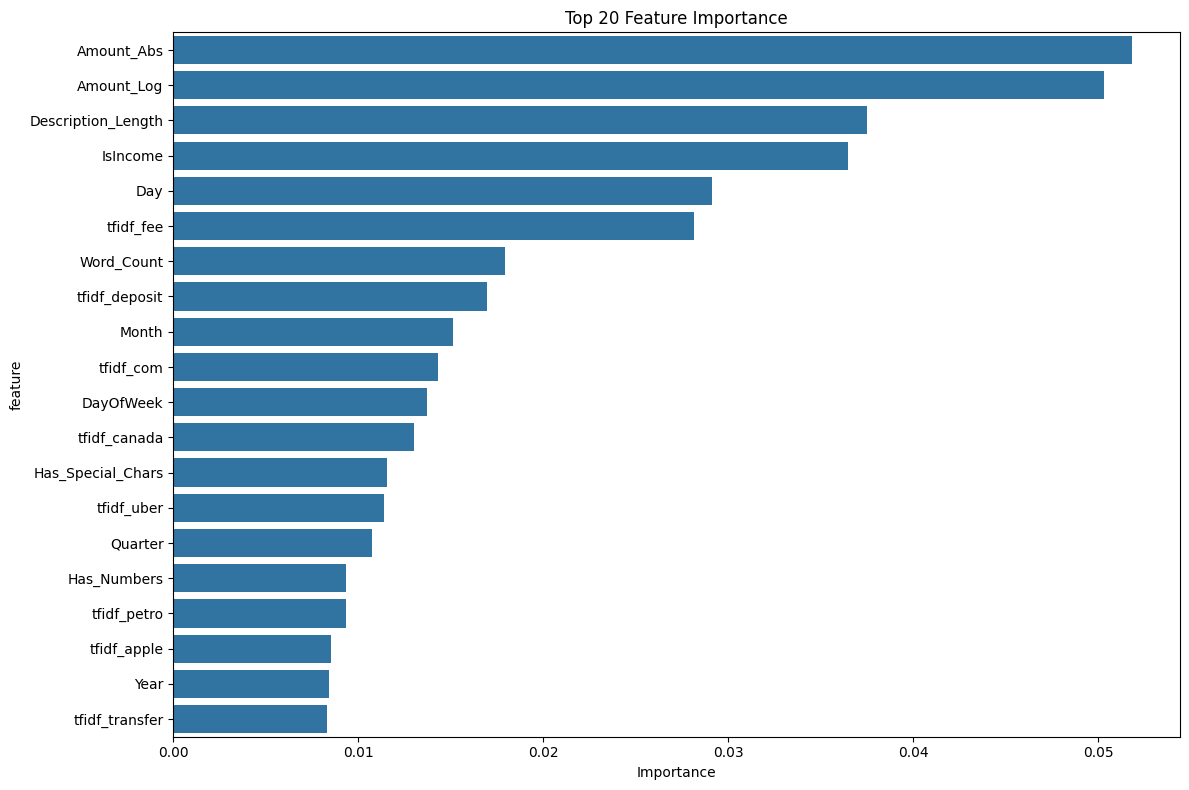


Top 10 Most Important TF-IDF Features:
             feature  importance
329        tfidf_fee    0.028143
290    tfidf_deposit    0.016980
265        tfidf_com    0.014287
202     tfidf_canada    0.013035
732       tfidf_uber    0.011386
545      tfidf_petro    0.009337
142      tfidf_apple    0.008503
715   tfidf_transfer    0.008331
143  tfidf_apple com    0.007807
199         tfidf_ca    0.007799

Basic Feature Importance:
               feature  importance
6           Amount_Abs    0.051837
8           Amount_Log    0.050307
9   Description_Length    0.037497
7             IsIncome    0.036492
2                  Day    0.029148
10          Word_Count    0.017918
1                Month    0.015110
3            DayOfWeek    0.013692
12   Has_Special_Chars    0.011534
5              Quarter    0.010747
11         Has_Numbers    0.009359
0                 Year    0.008445
4            IsWeekend    0.003783


In [37]:
# Analyze feature importance
print("Analyzing feature importance...")

# Get feature importance
feature_importance = best_rf_model.feature_importances_
feature_names = X_combined.columns

# Create importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(importance_df.head(20))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
sns.barplot(data=top_features, x='importance', y='feature')
plt.title('Top 20 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Analyze TF-IDF features specifically
tfidf_features = importance_df[importance_df['feature'].str.startswith('tfidf_')]
print(f"\nTop 10 Most Important TF-IDF Features:")
print(tfidf_features.head(10))

# Analyze basic features
basic_features = importance_df[~importance_df['feature'].str.startswith('tfidf_')]
print(f"\nBasic Feature Importance:")
print(basic_features)


## 9. Model Saving and Prediction Function


In [38]:
import joblib
import pickle

# Save the trained model and preprocessing objects
print("Saving improved model and preprocessing objects...")

# Create a dictionary with all necessary objects
model_package = {
    'model': rf_model,  # Use the improved model
    'tfidf_vectorizer': tfidf,
    'feature_columns': feature_columns,
    'class_names': rf_model.classes_,
    'feature_importance': importance_df
}

# Save to file
model_path = '../models/account_predictor_model_improved.pkl'
joblib.dump(model_package, model_path)

print(f"Improved model saved to: {model_path}")

# Create a prediction function
def predict_account(date, description, amount):
    """
    Predict account category for a new transaction
    
    Parameters:
    - date: Transaction date (string or datetime)
    - description: Transaction description (string)
    - amount: Transaction amount (float)
    
    Returns:
    - predicted_account: Predicted account category
    - confidence: Prediction confidence score
    """
    
    # Create a single-row DataFrame
    new_transaction = pd.DataFrame({
        'Date': [pd.to_datetime(date)],
        'Description': [description],
        'Amount': [amount]
    })
    
    # Create features (same as training)
    new_transaction['Year'] = new_transaction['Date'].dt.year
    new_transaction['Month'] = new_transaction['Date'].dt.month
    new_transaction['Day'] = new_transaction['Date'].dt.day
    new_transaction['DayOfWeek'] = new_transaction['Date'].dt.dayofweek
    new_transaction['IsWeekend'] = (new_transaction['DayOfWeek'] >= 5).astype(int)
    new_transaction['Quarter'] = new_transaction['Date'].dt.quarter
    
    new_transaction['Amount_Abs'] = new_transaction['Amount'].abs()
    new_transaction['IsIncome'] = (new_transaction['Amount'] > 0).astype(int)
    new_transaction['Amount_Log'] = np.log1p(new_transaction['Amount_Abs'])
    
    new_transaction['Description_Length'] = new_transaction['Description'].str.len()
    new_transaction['Word_Count'] = new_transaction['Description'].str.split().str.len()
    new_transaction['Has_Numbers'] = new_transaction['Description'].str.contains(r'\d').astype(int)
    new_transaction['Has_Special_Chars'] = new_transaction['Description'].str.contains(r'[!@#$%^&*(),.?":{}|<>]').astype(int)
    
    # Clean description for TF-IDF
    new_transaction['Description_Clean'] = new_transaction['Description'].apply(clean_text)
    
    # Create TF-IDF features
    tfidf_features = tfidf.transform(new_transaction['Description_Clean'])
    tfidf_df_new = pd.DataFrame(
        tfidf_features.toarray(),
        columns=[f'tfidf_{word}' for word in tfidf.get_feature_names_out()]
    )
    
    # Combine features
    X_new = pd.concat([new_transaction[feature_columns], tfidf_df_new], axis=1)
    
    # Ensure same columns as training data
    X_new = X_new.reindex(columns=X_combined.columns, fill_value=0)
    
    # Make prediction
    prediction = best_rf_model.predict(X_new)[0]
    confidence = best_rf_model.predict_proba(X_new).max()
    
    return prediction, confidence

# Test the prediction function
print("\nTesting prediction function...")
test_prediction, test_confidence = predict_account(
    '2024-01-15', 
    'Office Supplies - Staples', 
    -45.50
)
print(f"Test prediction: {test_prediction} (confidence: {test_confidence:.3f})")


Saving improved model and preprocessing objects...
Improved model saved to: ../models/account_predictor_model_improved.pkl

Testing prediction function...
Test prediction: Meals and Entertainment (confidence: 0.455)


## 10. Summary and Next Steps


In [39]:
# Final Summary
print("="*60)
print("ACCOUNT PREDICTOR MODEL - TRAINING COMPLETE")
print("="*60)

print(f"📊 Dataset: {len(df)} transactions")
print(f"🎯 Account Categories: {y.nunique()}")
print(f"🔧 Features Created: {X_combined.shape[1]}")
print(f"📈 Test Accuracy: {test_accuracy:.1%}")
print(f"💾 Model Saved: {model_path}")

print(f"\n🏆 Top 5 Most Important Features:")
for i, (_, row) in enumerate(importance_df.head(5).iterrows(), 1):
    print(f"{i}. {row['feature']}: {row['importance']:.4f}")

print(f"\n✅ Model is ready for predictions!")
print(f"Use the predict_account() function to classify new transactions.")

# Example predictions
print(f"\n🔮 Example Predictions:")
examples = [
    ("2024-01-15", "Office Supplies - Staples", -45.50),
    ("2024-01-16", "Client Payment - ABC Corp", 2500.00),
    ("2024-01-17", "Electricity Bill - ConEd", -120.75),
    ("2024-01-18", "Software Subscription - Adobe", -29.99),
    ("2024-01-19", "Business Lunch - Restaurant", -85.00)
]

for date, desc, amount in examples:
    pred, conf = predict_account(date, desc, amount)
    print(f"  {desc} (${amount}) → {pred} ({conf:.1%} confidence)")

print(f"\n🚀 Next Steps:")
print(f"1. Test the model with more of your data")
print(f"2. Add more transactions to improve accuracy")
print(f"3. Fine-tune account categories if needed")
print(f"4. Deploy the model for daily use")
print("="*60)


ACCOUNT PREDICTOR MODEL - TRAINING COMPLETE
📊 Dataset: 2445 transactions
🎯 Account Categories: 14
🔧 Features Created: 781
📈 Test Accuracy: 92.6%
💾 Model Saved: ../models/account_predictor_model_improved.pkl

🏆 Top 5 Most Important Features:
1. Amount_Abs: 0.0518
2. Amount_Log: 0.0503
3. Description_Length: 0.0375
4. IsIncome: 0.0365
5. Day: 0.0291

✅ Model is ready for predictions!
Use the predict_account() function to classify new transactions.

🔮 Example Predictions:
  Office Supplies - Staples ($-45.5) → Meals and Entertainment (45.5% confidence)
  Client Payment - ABC Corp ($2500.0) → Sales (50.0% confidence)
  Electricity Bill - ConEd ($-120.75) → Meals and Entertainment (38.0% confidence)
  Software Subscription - Adobe ($-29.99) → Meals and Entertainment (44.5% confidence)
  Business Lunch - Restaurant ($-85.0) → Meals and Entertainment (47.0% confidence)

🚀 Next Steps:
1. Test the model with more of your data
2. Add more transactions to improve accuracy
3. Fine-tune account cat

In [40]:
# Test the improved model with sample predictions
print("Testing model with sample predictions...")

def predict_single_transaction(date, description, amount):
    """Predict account for a single transaction"""
    # Create features for new transaction
    new_transaction = pd.DataFrame({
        'Date': [pd.to_datetime(date)],
        'Description': [description],
        'Amount': [amount]
    })
    
    # Date features
    new_transaction['Year'] = new_transaction['Date'].dt.year
    new_transaction['Month'] = new_transaction['Date'].dt.month
    new_transaction['Day'] = new_transaction['Date'].dt.day
    new_transaction['DayOfWeek'] = new_transaction['Date'].dt.dayofweek
    new_transaction['IsWeekend'] = (new_transaction['DayOfWeek'] >= 5).astype(int)
    new_transaction['Quarter'] = new_transaction['Date'].dt.quarter
    
    # Amount features
    new_transaction['Amount_Abs'] = new_transaction['Amount'].abs()
    new_transaction['IsIncome'] = (new_transaction['Amount'] > 0).astype(int)
    new_transaction['Amount_Log'] = np.log1p(new_transaction['Amount_Abs'])
    
    # Description features
    new_transaction['Description_Length'] = new_transaction['Description'].str.len()
    new_transaction['Word_Count'] = new_transaction['Description'].str.split().str.len()
    new_transaction['Has_Numbers'] = new_transaction['Description'].str.contains(r'\d').astype(int)
    new_transaction['Has_Special_Chars'] = new_transaction['Description'].str.contains(r'[!@#$%^&*(),.?":{}|<>]').astype(int)
    
    # Clean description
    new_transaction['Description_Clean'] = new_transaction['Description'].apply(clean_text)
    
    # TF-IDF features
    tfidf_features = tfidf.transform(new_transaction['Description_Clean'])
    tfidf_df_new = pd.DataFrame(
        tfidf_features.toarray(),
        columns=[f'tfidf_{word}' for word in tfidf.get_feature_names_out()]
    )
    
    # Combine features
    X_new = pd.concat([new_transaction[feature_columns], tfidf_df_new], axis=1)
    X_new = X_new.reindex(columns=X_combined.columns, fill_value=0)
    
    # Predict
    prediction = rf_model.predict(X_new)[0]
    confidence = rf_model.predict_proba(X_new).max()
    probabilities = rf_model.predict_proba(X_new)[0]
    prob_dict = dict(zip(rf_model.classes_, probabilities))
    
    return prediction, confidence, prob_dict

# Test cases
test_cases = [
    ("2024-01-15", "Office Supplies - Staples", -45.50, "Office Expense"),
    ("2024-01-16", "COSTCO WHOLESALE", -400.99, "Office Expense"),
    ("2024-01-17", "Client Payment - ABC Corp", 2500.00, "Sales"),
    ("2024-01-18", "STARBUCKS COFFEE", -7.42, "Meals and Entertainment"),
    ("2024-01-19", "Electricity Bill - ConEd", -120.75, "Office Expense"),
    ("2024-01-20", "PRE-AUTH PYMT - OTFS FEE BPY", -40.00, "Bank Charges")
]

print("Sample Predictions:")
print("="*80)
correct = 0
total = len(test_cases)

for date, desc, amount, expected in test_cases:
    prediction, confidence, probabilities = predict_single_transaction(date, desc, amount)
    top_3 = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)[:3]
    
    is_correct = prediction == expected
    if is_correct:
        correct += 1
    
    status = "✅" if is_correct else "❌"
    print(f"{status} {desc} (${amount})")
    print(f"   Expected: {expected}")
    print(f"   Predicted: {prediction} ({confidence:.1%})")
    print(f"   Top 3: {', '.join([f'{acc}: {prob:.1%}' for acc, prob in top_3])}")
    print()

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.1%} ({correct}/{total})")

if accuracy >= 0.7:
    print("🎉 Model is performing well!")
elif accuracy >= 0.5:
    print("⚠️  Model needs improvement")
else:
    print("❌ Model needs significant improvement")


Testing model with sample predictions...
Sample Predictions:
✅ Office Supplies - Staples ($-45.5)
   Expected: Office Expense
   Predicted: Office Expense (19.3%)
   Top 3: Office Expense: 19.3%, Meals and Entertainment: 17.9%, Bank Charges: 9.6%

✅ COSTCO WHOLESALE ($-400.99)
   Expected: Office Expense
   Predicted: Office Expense (19.1%)
   Top 3: Office Expense: 19.1%, Meals and Entertainment: 17.1%, Sales: 11.3%

✅ Client Payment - ABC Corp ($2500.0)
   Expected: Sales
   Predicted: Sales (28.8%)
   Top 3: Sales: 28.8%, Transfer Between Banks: 14.5%, Office Expense: 10.3%

✅ STARBUCKS COFFEE ($-7.42)
   Expected: Meals and Entertainment
   Predicted: Meals and Entertainment (21.2%)
   Top 3: Meals and Entertainment: 21.2%, Office Expense: 20.4%, Fees and Susbription: 10.4%

✅ Electricity Bill - ConEd ($-120.75)
   Expected: Office Expense
   Predicted: Office Expense (20.1%)
   Top 3: Office Expense: 20.1%, Meals and Entertainment: 18.9%, Fees and Susbription: 8.9%

✅ PRE-AUTH PYM